
# Analysis of Restraint and Seclusion Punishments Among Public Schools Between 2011-2012

Mental health facilities and other institutions have continuously worked towards eliminating the use of physical restraining or forced isolation as punishments towards children (especially those with disabilities), but public schools still do not have limits regarding use of such punishments. Legislation for Popular support for prohibiting schools from using restraint or seclusion can be observed through the reintroduction of the "Keeping All Students Safe Act" (KASSA) in Congress, but have yet to be actually passed. Additionally, the United States Department of Education states that schools that are compelled to repeatedly resort to restraint or seclusion to control children with disabilities are likely lacking in sufficient resources to provide all students with a fair, appropriate public education that they are required to have according to Section 504 of the Rehabilitation Act of 1973. In 2014, ProPublica released a dataset of 95,635 schools and their instances of the use of restraints and seclusions, which attempted to encompass all schools, districts, and their states nationally. However, the data is self reported and many school districts chose not to report, so we must proceed with caution. We can analyze this dataset for descriptive trends regarding public schools and their use of restraint and seclusion.

In this project, we will focus on investigating the following questions:
- Which punishment is the most frequent?
- Which states are underrepresented or overrepresented in the data set?
- Is there a relationship between district funding and use of restraint and seclusion? 

First, we will prepare our datasets.

In [50]:
## Reading in the Data
import numpy as np
import pandas as pd
from scipy import stats
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_excel("/Users/maggiejiang/Downloads/restraints_seclusions.xlsx")

#first three rows are printed
dataset.head(3)

,State,leaid,District_name,schid,School_name,combokey,total_enrollment,justice_facility,idea_mech_restraints,idea_phys_restraints,idea_seclusion,section_504_mech_restraints,section_504_phys_restraints,section_504_seclusion,no_dis_mech_restraints,no_dis_phys_restraints,no_dis_seclusion,propublica_dirty,incomplete
0,AK,200001,LOWER KUSKOKWIM SCHOOL DISTRICT,206,JOANN A. ALEXIE MEMORIAL SCHOOL,20000100206,103,NaN,0,0,0,0,0,0,0,0,0,f,NaN
1,AK,200001,LOWER KUSKOKWIM SCHOOL DISTRICT,207,GLADYS JUNG ELEMENTARY,20000100207,343,NaN,0,0,0,0,0,0,0,0,0,f,NaN
2,AK,200001,LOWER KUSKOKWIM SCHOOL DISTRICT,208,BETHEL REGIONAL HIGH SCHOOL,20000100208,476,NaN,0,0,0,0,0,0,0,0,0,f,NaN


In [51]:
#last three rows are printed
dataset.tail(3)

,State,leaid,District_name,schid,School_name,combokey,total_enrollment,justice_facility,idea_mech_restraints,idea_phys_restraints,idea_seclusion,section_504_mech_restraints,section_504_phys_restraints,section_504_seclusion,no_dis_mech_restraints,no_dis_phys_restraints,no_dis_seclusion,propublica_dirty,incomplete
95632,WY,5680251,WYOMING DEPARTMENT OF FAMILY SERVICES,534,WYOMING GIRLS SCHOOL,568025100534,36,Z,0,0,0,0,0,0,0,0,0,t,NaN
95633,WY,5680251,WYOMING DEPARTMENT OF FAMILY SERVICES,538,WYOMING BOYS SCHOOL,568025100538,73,Z,0,0,11,0,0,0,0,0,11,t,NaN
95634,WY,5680252,"YOUTH EMERGENCY SERVICES, INC. - ADMINISTRATIO...",350,"YOUTH EMERGENCY SERVICES, INC.",568025200350,94,NaN,0,0,0,0,0,0,0,0,0,f,NaN


# Checking for Statistical Trends

Our dataset contains the data of schools. We will begin analyzing the dataset for the answers to the following questions:

- Which punishment is the most frequent? Which type of student is most frequently punished?
- Which states are underrepresented or overrepresented in the data set?
- Is there a relationship between district funding and use of restraint and seclusion? 

We will start with the first question through retreiving the most frequent outcomes.

idea_phys_restraints           152476
idea_seclusion                  92480
no_dis_phys_restraints          22069
no_dis_seclusion                20126
no_dis_mech_restraints          10485
idea_mech_restraints             7843
section_504_phys_restraints       694
section_504_seclusion             615
section_504_mech_restraints       124
dtype: int64


Text(0, 0.5, 'Frequency')

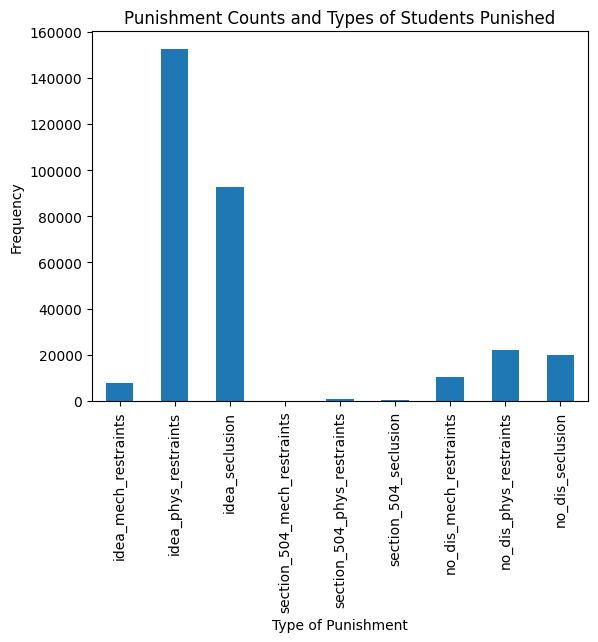

In [52]:
punishment_totals = dataset[['idea_mech_restraints', 'idea_phys_restraints', 'idea_seclusion', 'section_504_mech_restraints', 'section_504_phys_restraints', 'section_504_seclusion', 'no_dis_mech_restraints','no_dis_phys_restraints', 'no_dis_seclusion']]
punishment_sum = punishment_totals.sum()
print(punishment_sum.sort_values(ascending=False))
punishment_sum.plot(kind = 'bar')
plt.title('Punishment Counts and Types of Students Punished')
plt.xlabel('Type of Punishment')
plt.ylabel('Frequency')

Count of Punishment Instances towards students covered by the Individuals with Disabilities Act: 252799
Count of Punishment Instances towards students covered by Section 504 of the Rehabilitation Act: 1433
Count of Punishment Instances towards students without disabilities: 52680
Total Count of All Punishment Instances: 306912


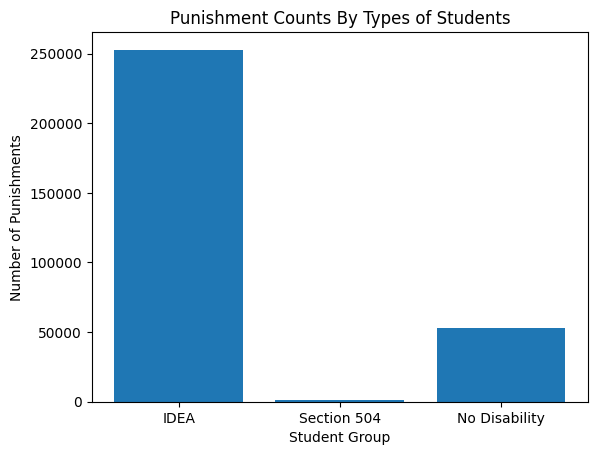

In [53]:
IDEA_sum = dataset[['idea_mech_restraints', 'idea_phys_restraints', 'idea_seclusion']].sum().sum()
section504_sum = dataset [['section_504_mech_restraints', 'section_504_phys_restraints', 'section_504_seclusion']].sum().sum()
nodis_sum = dataset[['no_dis_mech_restraints','no_dis_phys_restraints', 'no_dis_seclusion']].sum().sum()
groups = ['IDEA', 'Section 504', 'No Disability']
values = [IDEA_sum, section504_sum, nodis_sum]
plt.bar(groups, values)
plt.title('Punishment Counts By Types of Students')
plt.xlabel('Student Group')
plt.ylabel('Number of Punishments')

total_sum = punishment_sum.sum()
print('Count of Punishment Instances towards students covered by the Individuals with Disabilities Act: ' + str(IDEA_sum))
print('Count of Punishment Instances towards students covered by Section 504 of the Rehabilitation Act: ' + str(section504_sum))
print('Count of Punishment Instances towards students without disabilities: ' + str(nodis_sum))
print('Total Count of All Punishment Instances: ' + str(total_sum))

Mechanical Restraint Instances Count: 18452
Physical Restraint Instances Count: 175239
Seclusion Instances Count: 113221


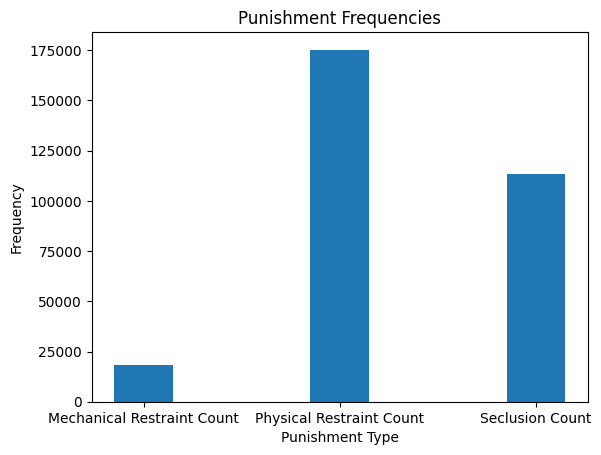

In [54]:
mechrestraint_sum = dataset[['idea_mech_restraints', 'section_504_mech_restraints', 'no_dis_mech_restraints']].sum().sum()
physrestraint_sum = dataset[['idea_phys_restraints', 'section_504_phys_restraints', 'no_dis_phys_restraints']].sum().sum()
seclusion_sum = dataset[['idea_seclusion','section_504_seclusion', 'no_dis_seclusion']].sum().sum()
xgroups = ('Mechanical Restraint Count', 'Physical Restraint Count', 'Seclusion Count')
yvalues = (mechrestraint_sum, physrestraint_sum, seclusion_sum)
plt.bar(xgroups, yvalues, width = 0.3)
plt.title('Punishment Frequencies')
plt.xlabel('Punishment Type')
plt.ylabel('Frequency')

print('Mechanical Restraint Instances Count: ' + str(mechrestraint_sum))
print('Physical Restraint Instances Count: ' + str(physrestraint_sum))
print('Seclusion Instances Count: ' + str(seclusion_sum))


### Each Type of Punishment

Mech Restraint 
- This indicates mechanical restraint, which refers to the usage of a device or equipment in order to immobilize the student or reduce the student's capability of movement 

Physical Restraints
- This indicates physical restraint, which involves holding a student down in order to immobilize the student or reduce the student's capability of movement 

Seclusion 
- Seclusion refers to the confinement of a student and prevent them from leaving a room, often involves locking them away and being unmonitored
- According to the ACLU in Washington, seclusion often involves tiny confimenments built soley for punishing students, and are closet sized, padded, fitted with a lock, and often found in special education classrooms

### IDEA vs Section 504 
- IDEA refers to Individuals with Disabilites Act of 1975
    - provides an IEP, or Individualized Education Program, which are legally binding contracts for the school to ensure they have accommodations for school deemed necessary  
    - for students who fall under one of the 13 disability categories, which include autism, deaf-blindness, and others AND require a special education in order to make progress at school
    - around 6.4 million students were covered by IDEA in 2011-2012
- Section 504 refers to Section 504 of the Rehabilitation Act of 1973
    - prohibits discrimination against individuals with disabilities and provides accommodations such as additional working time
        - the focus is on providing equal access to education, not necessarily making specialized education plans
    - for students who have a disability that limits a major life activity (much broader eligibility due to defining disability more expansively)
    - around 750,000 students were covered by Section 504 of the Rehabilitation Act in 2011-2012
- Typically, a student only has an IEP (Individualized Education Program) or Section 504 accommodations, but not both
    - This is because Section 504 is broader and students with only a Section 504 plan may not qualify for an IEP, and an IEP includes Section 504 protections

### Concluding Observations
We have determined that physical restraint is the most common type of punishment, and that students covered under IDEA are typically punished the most. We can attribute this to **** and
potential solutions, now that we know where to target the most



-states that are underrepresented in dataset(look for reasons why- chose to not report? something suspicious going on there?)
-states that are overrepresented in dataset (look for reasons why)
    -bar graph to look at both

-two way table for school districts with most and least amount of punishments and then to affluence measure
    -observe race demographics of the overrepresented school districts

text 
-add historical and social context + behavioral/cultural factors for the patterns observed in the data
-bias and limitations in data
-solutions for the future
-summary with findings

# Additional Readings

ProPublica and NPR Article
https://www.propublica.org/article/schools-restraints-seclusions?_gl=1*2wywmv*_ga*Nzc4OTY5MjYwLjE3NzU3MTM3NjU.*_ga_K9RW8M6GL5*czE3NzU3MjUzNDMkbzMkZzEkdDE3NzU3MjU1NzckajQ1JGwwJGgw

Definitions of Restraint and Isolation (Office for Civil Rights)
https://www.ed.gov/sites/ed/files/about/offices/list/ocr/docs/20190725-students-with-disabilities-and-use-of-rs.pdf

Students with Disabilities National Center for Education Statistics
https://nces.ed.gov/programs/coe/pdf/coe_cgg.pdf#:~:text=From%20school%20year%202000–01%20through%202004–05%2C%20the,14%20percent%20of%20total%20public%20school%20enrollment.